# FAI Capstone — Experiment 2: Four-Algorithm Head-to-Head Comparison

---

## What We Test
All four TD control algorithms compared head-to-head across five Gymnasium environments — the main empirical contribution of the project.

| Environment | States | Actions | Stochasticity | Risk |
|---|---|---|---|---|
| FrozenLake 4×4 (det) | 16 | 4 | None | Holes |
| FrozenLake 4×4 (slip) | 16 | 4 | Slippery | Holes |
| FrozenLake 8×8 (det) | 64 | 4 | None | Holes |
| FrozenLake 8×8 (slip) | 64 | 4 | Slippery | Holes |
| CliffWalking | 48 | 4 | None | −100 cliff edge |
| Taxi-v3 | 500 | 6 | None | Illegal pickup/dropoff |

## Hypotheses
| | Hypothesis |
|---|---|
| **H1** | Q-learning outperforms SARSA on deterministic environments |
| **H2** | Double Q-learning outperforms Q-learning on stochastic FrozenLake |
| **H3** | SARSA achieves better cumulative reward on CliffWalking (safer path = fewer −100 penalties) |
| **H4** | Expected SARSA is consistently second-best across all environments |
| **H5** | All algorithms degrade on Taxi-v3 but ranking mirrors smaller environments |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os

# Project root on Drive
PROJECT_ROOT = "/content/drive/MyDrive/Study Materials/Semester 2/FAI/FAI_Capstone_Project"

# Create folder structure if it doesn't exist yet
os.makedirs(f"{PROJECT_ROOT}/notebooks", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/src",       exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/results/exp1", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/results/exp2", exist_ok=True)

print("Drive mounted.")
print(f"Project root: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Project root: /content/drive/MyDrive/Study Materials/Semester 2/FAI/FAI_Capstone_Project


# 2. Imports & Experiment Config



This cell imports necessary libraries for the experiment and defines global configuration parameters. The values for `ALPHA`, `EPSILON`, and `MAX_STEPS` were chosen based on the findings from Experiment 1, where they demonstrated the best performance for the TD control algorithms in similar environments. `N_SEEDS` is set to ensure statistical significance, `N_EPISODES` is increased to allow for convergence in larger environments, and `GAMMA` remains high to emphasize future rewards. The `EXP2_ENVS` list specifies all environments included in this head-to-head comparison.

In [ ]:
# Imports & Experiment Config
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from tqdm import tqdm
from joblib import Parallel, delayed
import pickle, os, warnings
warnings.filterwarnings('ignore')

import gymnasium as gym

# Experiment config
N_SEEDS    = 30
N_EPISODES = 5000     # more than Exp 1 -- larger environments need more runway
GAMMA      = 0.99
ALPHA      = 0.1      # constant alpha -- fastest convergence in Exp 1
EPSILON    = 0.1      # epsilon-greedy -- greedy was catastrophic in Exp 1
MAX_STEPS  = 200      # tighter cap than Exp 1's 500 (CliffWalking/Taxi need this)
SMOOTH_W   = 50       # smoothing window for convergence plots

SAVE_DIR = "/content/drive/MyDrive/Study Materials/Semester 2/FAI/FAI_Capstone_Project/results/exp2"
os.makedirs(SAVE_DIR, exist_ok=True)

EXP2_ENVS = [
    'frozen_lake_4x4_det',
    'frozen_lake_4x4_slip',
    'frozen_lake_8x8_det',
    'frozen_lake_8x8_slip',
    'cliff_walking',
    'taxi',
]

print(f'Config: {N_SEEDS} seeds | {N_EPISODES} episodes | alpha={ALPHA} | epsilon={EPSILON} | gamma={GAMMA} | MAX_STEPS={MAX_STEPS}')
print(f'Environments: {len(EXP2_ENVS)} | Algorithms: 4')
print(f'Total training episodes: {N_SEEDS * N_EPISODES * len(EXP2_ENVS) * 4:,}')

Config: 30 seeds | 5000 episodes | alpha=0.1 | epsilon=0.1 | gamma=0.99 | MAX_STEPS=200
Environments: 6 | Algorithms: 4
Total training episodes: 3,600,000


# 3. Environment Layer


This cell defines the `GymnasiumEnv` class. Its primary purpose is to standardize how different environments are accessed and interacted with throughout the experiment.

**The Functionality:**
*   **`_REGISTRY`**: A static dictionary used for mapping internal environment keys (for e.g., `'frozen_lake_4x4_det'`) to their corresponding Gymnasium ID, specific `make_kwargs` (e.g., `map_name`, `is_slippery`), number of states, number of actions, and a display name. This centralizes environment configuration.
*   **`make(key)`**: A class method that acts as a factory, ensuring that a fresh instance of an environment is created for each call. This is important when running simulations in parallel (e.g., across multiple seeds) to avoid shared state issues.
*   **`reset()`**: Resets the environment and returns the initial observation as an integer.
*   **`step(action)`**: Takes an action, advances the environment, and returns the next observation, reward, and a `done` flag (used for indicating termination), all in consistent integer,float or boolean formats.
*   **`get_transition_model()`**: Provides access to the environment's internal transition model (`env.unwrapped.P`), which is essential for algorithms like Value Iteration to pre-compute the optimal Q-values (`Q*`).

In [ ]:
# Environment Layer

class GymnasiumEnv:
    """Thin wrapper around a Gymnasium discrete environment."""

    _REGISTRY = {
        # key: (gym_id, make_kwargs, n_states, n_actions, display_name)
        'frozen_lake_4x4_det':  ('FrozenLake-v1',  {'map_name': '4x4', 'is_slippery': False}, 16,  4, 'FrozenLake 4x4 (det)'),
        'frozen_lake_4x4_slip': ('FrozenLake-v1',  {'map_name': '4x4', 'is_slippery': True},  16,  4, 'FrozenLake 4x4 (slip)'),
        'frozen_lake_8x8_det':  ('FrozenLake-v1',  {'map_name': '8x8', 'is_slippery': False}, 64,  4, 'FrozenLake 8x8 (det)'),
        'frozen_lake_8x8_slip': ('FrozenLake-v1',  {'map_name': '8x8', 'is_slippery': True},  64,  4, 'FrozenLake 8x8 (slip)'),
        'cliff_walking':        ('CliffWalking-v1', {},                                        48,  4, 'CliffWalking'),
        'taxi':                 ('Taxi-v3',          {},                                       500,  6, 'Taxi-v3'),
    }

    @classmethod
    def make(cls, key):
        """Factory -- always creates a fresh env instance (required for parallelism)."""
        gym_id, kwargs, n_states, n_actions, display_name = cls._REGISTRY[key]
        return cls(gym_id, kwargs, n_states, n_actions, display_name, key)

    def __init__(self, gym_id, kwargs, n_states, n_actions, display_name, key):
        self._gym_id   = gym_id
        self._kwargs   = kwargs
        self.n_states  = n_states
        self.n_actions = n_actions
        self.name      = display_name
        self.key       = key
        self._env      = gym.make(gym_id, **kwargs)

    def reset(self):
        obs, _ = self._env.reset()
        return int(obs)

    def step(self, action):

        obs, reward, terminated, truncated, _ = self._env.step(int(action))
        done = terminated or truncated
        return int(obs), float(reward), bool(done)

    def get_transition_model(self):
        """Returns env.unwrapped.P for Value Iteration.
        Format: {s: {a: [(prob, next_state, reward, terminated), ...]}}
        """
        return self._env.unwrapped.P


# Smoke test
print(f"{'Key':<25} {'Name':<25} {'States':>7} {'Actions':>8}")
print('-' * 68)
for key in EXP2_ENVS:
    e = GymnasiumEnv.make(key)
    print(f'{key:<25} {e.name:<25} {e.n_states:>7} {e.n_actions:>8}')
print('\nAll environments OK.')

Key                       Name                       States  Actions
--------------------------------------------------------------------
frozen_lake_4x4_det       FrozenLake 4x4 (det)           16        4
frozen_lake_4x4_slip      FrozenLake 4x4 (slip)          16        4
frozen_lake_8x8_det       FrozenLake 8x8 (det)           64        4
frozen_lake_8x8_slip      FrozenLake 8x8 (slip)          64        4
cliff_walking             CliffWalking                   48        4
taxi                      Taxi-v3                       500        6

All environments OK.


# 4. Value Iteration & Pre-compute Q*

This cell pre-computes the optimal Q-value function (Q*) for each environment in `EXP2_ENVS`. Its primary purpose is to establish a 'ground truth' for subsequent analysis, specifically for calculating the Root Mean Square Error (RMSE) of the learning algorithms.


**Some Output Insights:**
*   The code loops through each defined environment, creates an instance using `GymnasiumEnv.make()`, and calls `value_iteration_gym` to get `Q_star` and `V_star`.
*   The printed output confirms that `Q_star` has been computed, showing its shape (e.g., `(16, 4)` for a 16-state, 4-action environment). It also displays `V*(s0)`, the optimal value of the initial state. For cost environments like `CliffWalking` (where every step incurs a -1 penalty), it's expected that `V*(s0)` will be a negative value, reflecting the accumulated costs along the optimal path.

In [ ]:
# Value Iteration (Gymnasium) & Pre-compute Q*

def value_iteration_gym(env, gamma=GAMMA, theta=1e-9):
    """
    Tabular value iteration for any Gymnasium discrete environment.
    Uses env.unwrapped.P: {s: {a: [(prob, ns, reward, terminated), ...]}}
    Returns Q_star (n_states x n_actions) and V_star (n_states,).
    """
    P        = env.get_transition_model()
    n_s, n_a = env.n_states, env.n_actions
    V        = np.zeros(n_s)

    while True:
        delta = 0.0
        for s in range(n_s):
            v    = V[s]
            V[s] = max(
                sum(prob * (r + gamma * (0.0 if term else V[ns]))
                    for prob, ns, r, term in P[s][a])
                for a in range(n_a)
            )
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break

    Q_star = np.array([
        [sum(prob * (r + gamma * (0.0 if term else V[ns]))
             for prob, ns, r, term in P[s][a])
         for a in range(n_a)]
        for s in range(n_s)
    ])
    return Q_star, V


# Pre-compute Q* for all Exp 2 environments
print('Computing Q* via value iteration for all environments...')
print('(Taxi-v3 with 500 states may take ~15s)\n')

q_stars = {}

for key in EXP2_ENVS:
    env            = GymnasiumEnv.make(key)
    Q_star, V_star = value_iteration_gym(env)
    q_stars[key]   = Q_star
    s0             = env.reset()
    print(f'  {env.name:<25} Q* shape={Q_star.shape}  V*(s0)={V_star[s0]:+.4f}')

print('\nAll Q* tables ready.')

Computing Q* via value iteration for all environments...
(Taxi-v3 with 500 states may take ~15s)

  FrozenLake 4x4 (det)      Q* shape=(16, 4)  V*(s0)=+0.9510
  FrozenLake 4x4 (slip)     Q* shape=(16, 4)  V*(s0)=+0.5420
  FrozenLake 8x8 (det)      Q* shape=(64, 4)  V*(s0)=+0.8775
  FrozenLake 8x8 (slip)     Q* shape=(64, 4)  V*(s0)=+0.4146
  CliffWalking              Q* shape=(48, 4)  V*(s0)=-12.2479
  Taxi-v3                   Q* shape=(500, 6)  V*(s0)=+4.2495

All Q* tables ready.


# 5. Shared Utilities

This part of code defines a collection of shared utility functions that are critical for the execution and analysis of Experiment 2. These functions provide reusable components for common tasks across different algorithms and analysis steps.

**Functionality:**
*   **`select_action(Q, state, epsilon)`**: Implements the epsilon-greedy action selection strategy, balancing exploration and exploitation. It includes random tie-breaking to prevent deterministic action choices from zero-initialized Q-tables.
*   **`compute_policy_optimality(Q, Q_star)`**: Measures the similarity between a learned policy and the optimal policy (derived from Q*), expressed as the percentage of states where their greedy actions match.
*   **`compute_convergence_speed(reward_log, window, tol)`**: Determines the episode at which an agent's performance (based on a rolling mean of rewards) stabilizes within a given tolerance.
*   **`mean_ci(data, axis)`**: Calculates the mean and 95% confidence interval (CI) of numerical data, useful for summarizing results across multiple seeds.
*   **`smooth(arr, w)`**: Applies a simple moving average to an array, used for smoothing noisy data in plots for clearer visualization.

These utilities will be used by the algorithm implementations (e.g., `select_action`) and during the post-experiment analysis and plotting to process raw results (e.g., `compute_policy_optimality`, `mean_ci`, `smooth`).

In [ ]:
# Shared Utilities

def select_action(Q, state, epsilon):
    """
    Epsilon-greedy action selection.
    Ties in argmax broken randomly -- critical at start with zero-init Q-tables
    to prevent the agent from always locking onto action 0.
    """
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])
    q_row = Q[state]
    return int(np.random.choice(np.flatnonzero(q_row == q_row.max())))


def compute_policy_optimality(Q, Q_star):
    """
    Fraction of states where greedy action from Q matches greedy action from Q*.
    Returns a float in [0, 1].
    """
    learned = np.argmax(Q,      axis=1)
    optimal = np.argmax(Q_star, axis=1)
    return float((learned == optimal).mean())


def compute_convergence_speed(reward_log, window=100, tol=0.05):
    """
    Episode index at which the agent's performance stabilises.
    Defined as the first episode e where the window-ep rolling mean stays
    within tol of the final window-ep mean for the rest of training.
    Returns N_EPISODES if it never stabilises.
    """
    n = len(reward_log)
    if n < window:
        return n
    rolling = np.convolve(reward_log, np.ones(window) / window, mode='valid')
    final   = rolling[-window:].mean()
    denom   = max(abs(final), 1e-6)
    for i, val in enumerate(rolling):
        if np.all(np.abs(rolling[i:] - final) / denom <= tol):
            return i + window   # offset for valid-mode convolution
    return n


def mean_ci(data, axis=0):
    """Returns (mean, lower_95ci, upper_95ci) along the given axis."""
    mean = data.mean(axis=axis)
    ci   = 1.96 * stats.sem(data, axis=axis)
    return mean, mean - ci, mean + ci


def smooth(arr, w=SMOOTH_W):
    """Simple moving average -- matches the smoothing used in Exp 1 plots."""
    return np.convolve(arr, np.ones(w) / w, mode='valid')

# 6. All Four Algorithm Implementations

This code block contains the merged implementations of the four TD control algorithms (Q-learning, SARSA, Expected SARSA, and Double Q-learning) developed by the team for Experiment 2.

In [ ]:
# Algorithm Implementations

# Q-learning (Off-policy)

def run_qlearning(env, Q_star, seed):
    """
    Off-policy TD control (Watkins & Dayan, 1992).

    Bootstrap value: max_a Q(s', a)
    Assumes the optimal action will be taken next, regardless of the policy
    being followed. Fast on deterministic envs; overestimates on stochastic.
    """
    np.random.seed(seed)
    Q          = np.zeros((env.n_states, env.n_actions))
    reward_log = np.empty(N_EPISODES)
    rmse_log   = np.empty(N_EPISODES)

    for ep in range(N_EPISODES):
        s         = env.reset()
        done      = False
        ep_reward = 0.0

        for _ in range(MAX_STEPS):
            if done:
                break
            a           = select_action(Q, s, EPSILON)
            ns, r, done = env.step(a)
            ep_reward  += r
            # Off-policy bootstrap: max over next-state Q-values
            target      = r + GAMMA * Q[ns].max() * (not done)
            Q[s, a]    += ALPHA * (target - Q[s, a])
            s           = ns

        reward_log[ep] = ep_reward
        rmse_log[ep]   = np.sqrt(np.mean((Q - Q_star) ** 2))

    return Q, reward_log, rmse_log


# SARSA (On-policy)

def run_sarsa(env, Q_star, seed):
    """
    On-policy TD control (Rummery & Niranjan, 1994).

    Bootstrap value: Q(s', a') where a' is sampled from the current epsilon-greedy policy.
    Learns the value of the policy it is executing.
    """
    np.random.seed(seed)
    Q          = np.zeros((env.n_states, env.n_actions))
    reward_log = np.empty(N_EPISODES)
    rmse_log   = np.empty(N_EPISODES)

    for ep in range(N_EPISODES):
        s         = env.reset()
        a         = select_action(Q, s, EPSILON)
        done      = False
        ep_reward = 0.0

        for _ in range(MAX_STEPS):
            if done:
                break
            ns, r, done = env.step(a)
            na          = select_action(Q, ns, EPSILON)
            ep_reward  += r

            target      = r + GAMMA * Q[ns, na] * (not done)
            Q[s, a]    += ALPHA * (target - Q[s, a])
            s, a        = ns, na

        reward_log[ep] = ep_reward
        rmse_log[ep]   = np.sqrt(np.mean((Q - Q_star) ** 2))

    return Q, reward_log, rmse_log


# Expected SARSA (On-policy)

def run_expected_sarsa(env, Q_star, seed):

    np.random.seed(seed)
    Q          = np.zeros((env.n_states, env.n_actions))
    n_a        = env.n_actions
    reward_log = np.empty(N_EPISODES)
    rmse_log   = np.empty(N_EPISODES)

    for ep in range(N_EPISODES):
        s         = env.reset()
        done      = False
        ep_reward = 0.0

        for _ in range(MAX_STEPS):
            if done:
                break
            a           = select_action(Q, s, EPSILON)
            ns, r, done = env.step(a)
            ep_reward  += r


            probs                 = np.full(n_a, EPSILON / n_a)
            probs[Q[ns].argmax()] += (1.0 - EPSILON)
            expected_q            = float(np.dot(probs, Q[ns]))

            target  = r + GAMMA * expected_q * (not done)
            Q[s, a] += ALPHA * (target - Q[s, a])
            s        = ns

        reward_log[ep] = ep_reward
        rmse_log[ep]   = np.sqrt(np.mean((Q - Q_star) ** 2))

    return Q, reward_log, rmse_log


# Double Q-learning (Off-policy)

def run_double_qlearning(env, Q_star, seed):
    """
    Off-policy TD control with maximization bias correction (Van Hasselt, 2010).
    """
    np.random.seed(seed)
    Q1         = np.zeros((env.n_states, env.n_actions))
    Q2         = np.zeros((env.n_states, env.n_actions))
    reward_log = np.empty(N_EPISODES)
    rmse_log   = np.empty(N_EPISODES)

    for ep in range(N_EPISODES):
        s         = env.reset()
        done      = False
        ep_reward = 0.0

        for _ in range(MAX_STEPS):
            if done:
                break

            a           = select_action(Q1 + Q2, s, EPSILON)
            ns, r, done = env.step(a)
            ep_reward  += r

            if np.random.rand() < 0.5:

                a_star    = int(Q1[ns].argmax())
                target    = r + GAMMA * Q2[ns, a_star] * (not done)
                Q1[s, a] += ALPHA * (target - Q1[s, a])
            else:

                a_star    = int(Q2[ns].argmax())
                target    = r + GAMMA * Q1[ns, a_star] * (not done)
                Q2[s, a] += ALPHA * (target - Q2[s, a])

            s = ns

        reward_log[ep] = ep_reward
        Q_avg          = (Q1 + Q2) * 0.5
        rmse_log[ep]   = np.sqrt(np.mean((Q_avg - Q_star) ** 2))

    return (Q1 + Q2) * 0.5, reward_log, rmse_log


# Algorithm registry

ALGOS = {
    'Q-learning'       : run_qlearning,
    'SARSA'            : run_sarsa,
    'Expected SARSA'   : run_expected_sarsa,
    'Double Q-learning': run_double_qlearning,
}

ALGO_COLORS = {
    'Q-learning'       : '#e74c3c',   # red
    'SARSA'            : '#2ecc71',   # green
    'Expected SARSA'   : '#3498db',   # blue
    'Double Q-learning': '#9b59b6',   # purple
}

print('All four algorithms defined.\n')
print(f"{'Algorithm':<22} Bootstrap Target")
print('-' * 60)
print(f"{'Q-learning':<22} max_a Q(s', a)  [off-policy]")
print(f"{'SARSA':<22} Q(s', a') where a' ~ pi  [on-policy]")
print(f"{'Expected SARSA':<22} E[Q(s', a')] under pi  [on-policy, low variance]")
print(f"{'Double Q-learning':<22} Q2(s', argmax Q1(s',a))  [debiased]")

All four algorithms defined.

Algorithm              Bootstrap Target
------------------------------------------------------------
Q-learning             max_a Q(s', a)  [off-policy]
SARSA                  Q(s', a') where a' ~ pi  [on-policy]
Expected SARSA         E[Q(s', a')] under pi  [on-policy, low variance]
Double Q-learning      Q2(s', argmax Q1(s',a))  [debiased]


# 7. Run Experiment 2 (Rewards and RMSE)

We execute Experiment 2 by running all four TD control algorithms across all specified environments for `N_SEEDS` random seeds. It uses parallel processing to speed up the computations. For each (environment, algorithm) pair, it prints the average final cumulative reward and the average final Q-value RMSE. These numerical results offer an initial glimpse into algorithm performance across different environments, highlighting differences in how quickly and accurately they converge. These results have been visualized in the next few cells as reward and RMSE curves, providing a clearer understanding of the learning dynamics over all episodes.

In [ ]:
def run_single_seed(env_key, algo_fn, seed):
    """Run one (environment, algorithm, seed) triple. Called in parallel."""
    env    = GymnasiumEnv.make(env_key)
    Q_star = q_stars[env_key]
    Q, rewards, rmse = algo_fn(env, Q_star, seed)
    return rewards, rmse


total_runs = len(EXP2_ENVS) * len(ALGOS) * N_SEEDS
print(f'Starting Experiment 2')
print(f'  {len(EXP2_ENVS)} environments x {len(ALGOS)} algorithms x {N_SEEDS} seeds = {total_runs} total runs')
print()

results = {}

for env_key in EXP2_ENVS:
    env_name = GymnasiumEnv._REGISTRY[env_key][4]
    print(f'--- {env_name} ---')

    for algo_name, algo_fn in ALGOS.items():
        print(f'  {algo_name:<22}', end='', flush=True)

        outputs = Parallel(n_jobs=-1)(
            delayed(run_single_seed)(env_key, algo_fn, seed)
            for seed in range(N_SEEDS)
        )

        rewards = np.array([o[0] for o in outputs])
        rmse    = np.array([o[1] for o in outputs])

        results[(env_key, algo_name)] = {'rewards': rewards, 'rmse': rmse}

        final_r    = rewards[:, -100:].mean(axis=1).mean()
        final_rmse = rmse[:, -100:].mean(axis=1).mean()
        print(f'  final_reward={final_r:+7.3f}  final_RMSE={final_rmse:.4f}')

    print()

# Save results
with open(f'{SAVE_DIR}/exp2_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print(f'Results saved -> {SAVE_DIR}/exp2_results.pkl')

Starting Experiment 2
  6 environments x 4 algorithms x 30 seeds = 720 total runs

--- FrozenLake 4x4 (det) ---
  Q-learning              final_reward= +0.888  final_RMSE=0.3499
  SARSA                   final_reward= +0.880  final_RMSE=0.3303
  Expected SARSA          final_reward= +0.888  final_RMSE=0.3621
  Double Q-learning       final_reward= +0.889  final_RMSE=0.3741

--- FrozenLake 4x4 (slip) ---
  Q-learning              final_reward= +0.380  final_RMSE=0.0698
  SARSA                   final_reward= +0.383  final_RMSE=0.1661
  Expected SARSA          final_reward= +0.374  final_RMSE=0.1601
  Double Q-learning       final_reward= +0.334  final_RMSE=0.1453

--- FrozenLake 8x8 (det) ---
  Q-learning              final_reward= +0.910  final_RMSE=0.5741
  SARSA                   final_reward= +0.874  final_RMSE=0.5758
  Expected SARSA          final_reward= +0.909  final_RMSE=0.5854
  Double Q-learning       final_reward= +0.910  final_RMSE=0.5999

--- FrozenLake 8x8 (slip) ---
  Q-

# 8. Plot: Cumulative Reward Curves

 These plots produced from the experiment 2 are crucial for understanding the learning dynamics and performance trends of each algorithm.

**Key Insights from the Cumulative Reward Curves:**
1.  **Q-learning vs. SARSA on Deterministic FL:** In the deterministic FrozenLake environments (e.g., 'FrozenLake 4x4 (det)', 'FrozenLake 8x8 (det)'), Q-learning is expected to converge faster and achieve higher or comparable final rewards to SARSA. This is because Q-learning, being off-policy, can learn the optimal policy directly without being constrained by the exploratory actions of its own policy. SARSA, on the other hand, learns the value of the policy it is following, which includes potentially sub-optimal exploratory actions.
2.  **Double Q-learning vs. Q-learning on Stochastic FL:** On stochastic environments like 'FrozenLake 4x4 (slip)' and 'FrozenLake 8x8 (slip)', Q-learning often suffers from maximization bias, where it overestimates action values due to the max operator. While Double Q-learning is designed to mitigate this, its advantage in cumulative reward might not always be immediately apparent compared to its RMSE benefits. SARSA and Expected SARSA, being on-policy, might show more stable (or even higher) rewards in highly stochastic environments, as their updates account for the true expected value of actions taken under the current policy.
3.  **SARSA on CliffWalking:** For 'CliffWalking', SARSA and Expected SARSA are anticipated to significantly outperform Q-learning in terms of cumulative reward (i.e., achieve less negative rewards). This is because SARSA's on-policy nature makes it

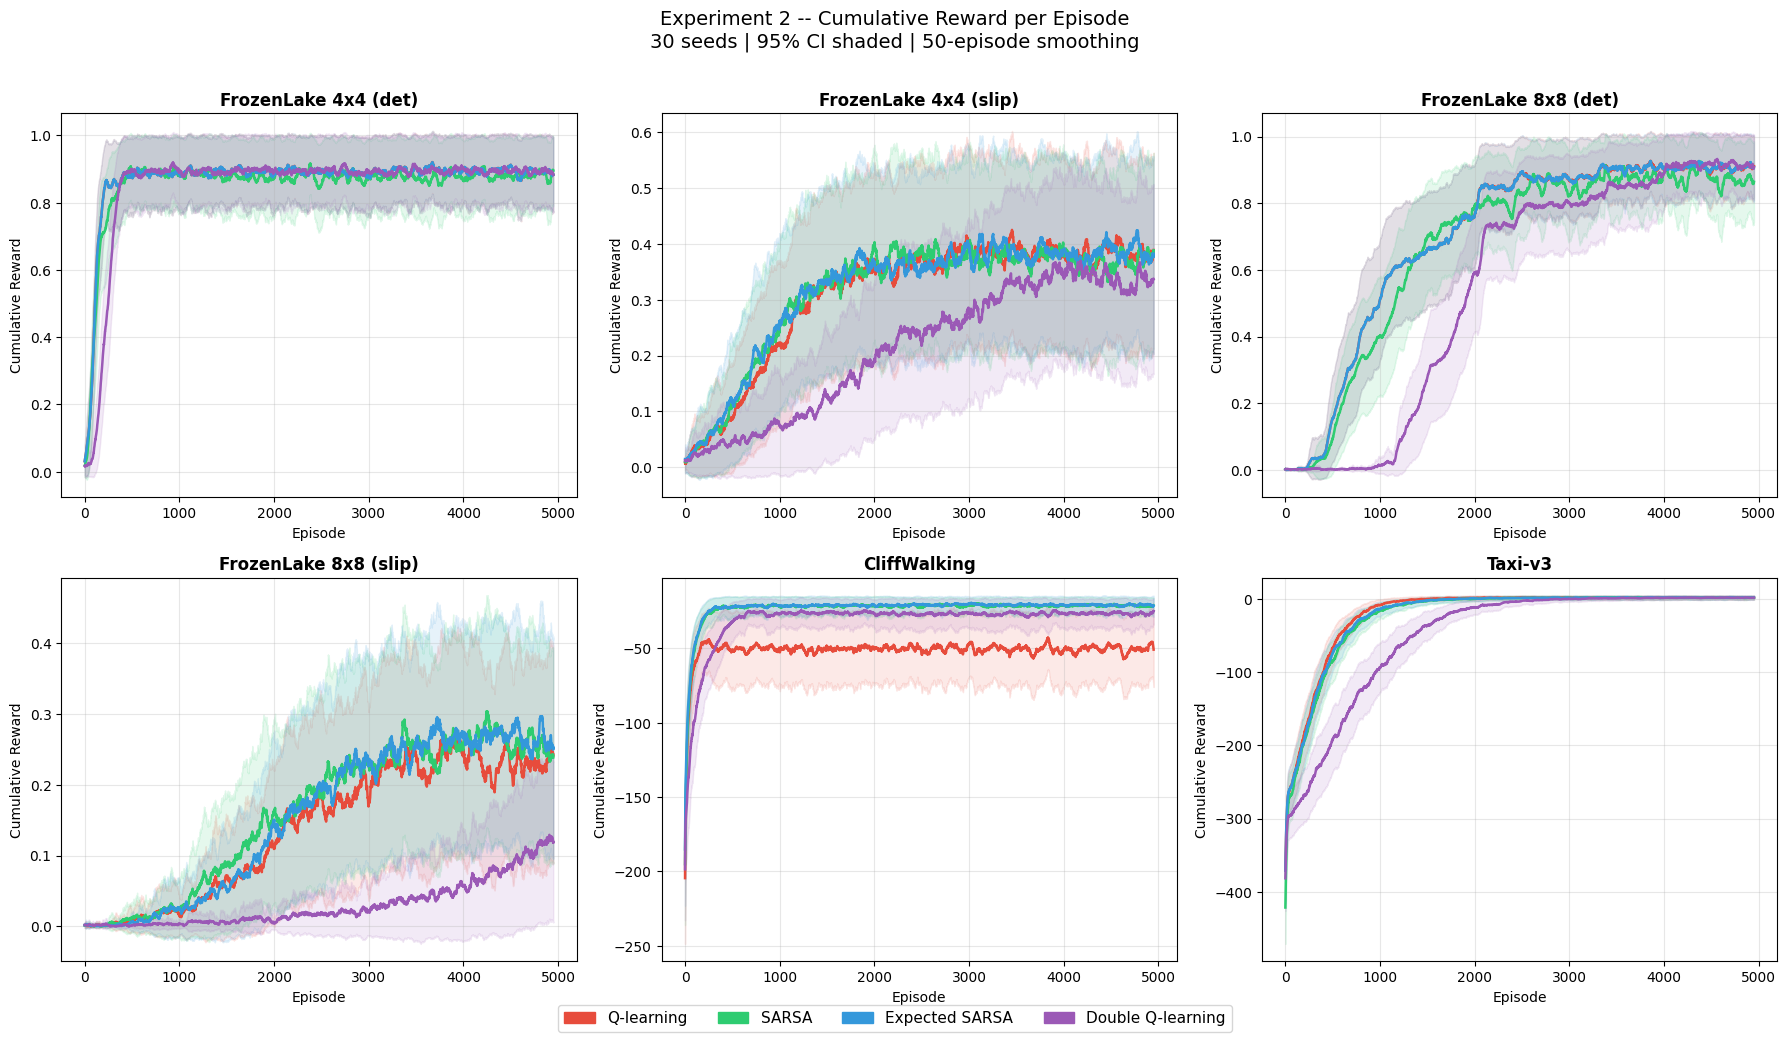

Saved: exp2_reward_curves.png


In [ ]:
# Cumulative Reward per Episode

episodes = np.arange(N_EPISODES)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes      = axes.flatten()

for idx, env_key in enumerate(EXP2_ENVS):
    ax       = axes[idx]
    env_name = GymnasiumEnv._REGISTRY[env_key][4]

    for algo_name in ALGOS:
        data         = results[(env_key, algo_name)]['rewards']   # (30, 5000)
        mean, lo, hi = mean_ci(data, axis=0)

        m_s  = smooth(mean)
        lo_s = smooth(lo)
        hi_s = smooth(hi)
        ep_s = episodes[:len(m_s)]

        color = ALGO_COLORS[algo_name]
        ax.plot(ep_s, m_s, color=color, linewidth=1.8, label=algo_name)
        ax.fill_between(ep_s, lo_s, hi_s, color=color, alpha=0.12)

    ax.set_title(env_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode', fontsize=10)
    ax.set_ylabel('Cumulative Reward', fontsize=10)
    ax.grid(True, alpha=0.3)

legend_patches = [mpatches.Patch(color=ALGO_COLORS[a], label=a) for a in ALGOS]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f'Experiment 2 -- Cumulative Reward per Episode\n'
    f'{N_SEEDS} seeds | 95% CI shaded | {SMOOTH_W}-episode smoothing',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/exp2_reward_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp2_reward_curves.png')

# 9. Plot: Q-Value RMSE Curves

These plots help evaluate how accurately each algorithm estimates the true optimal Q-values (`Q*`) over the course of training.

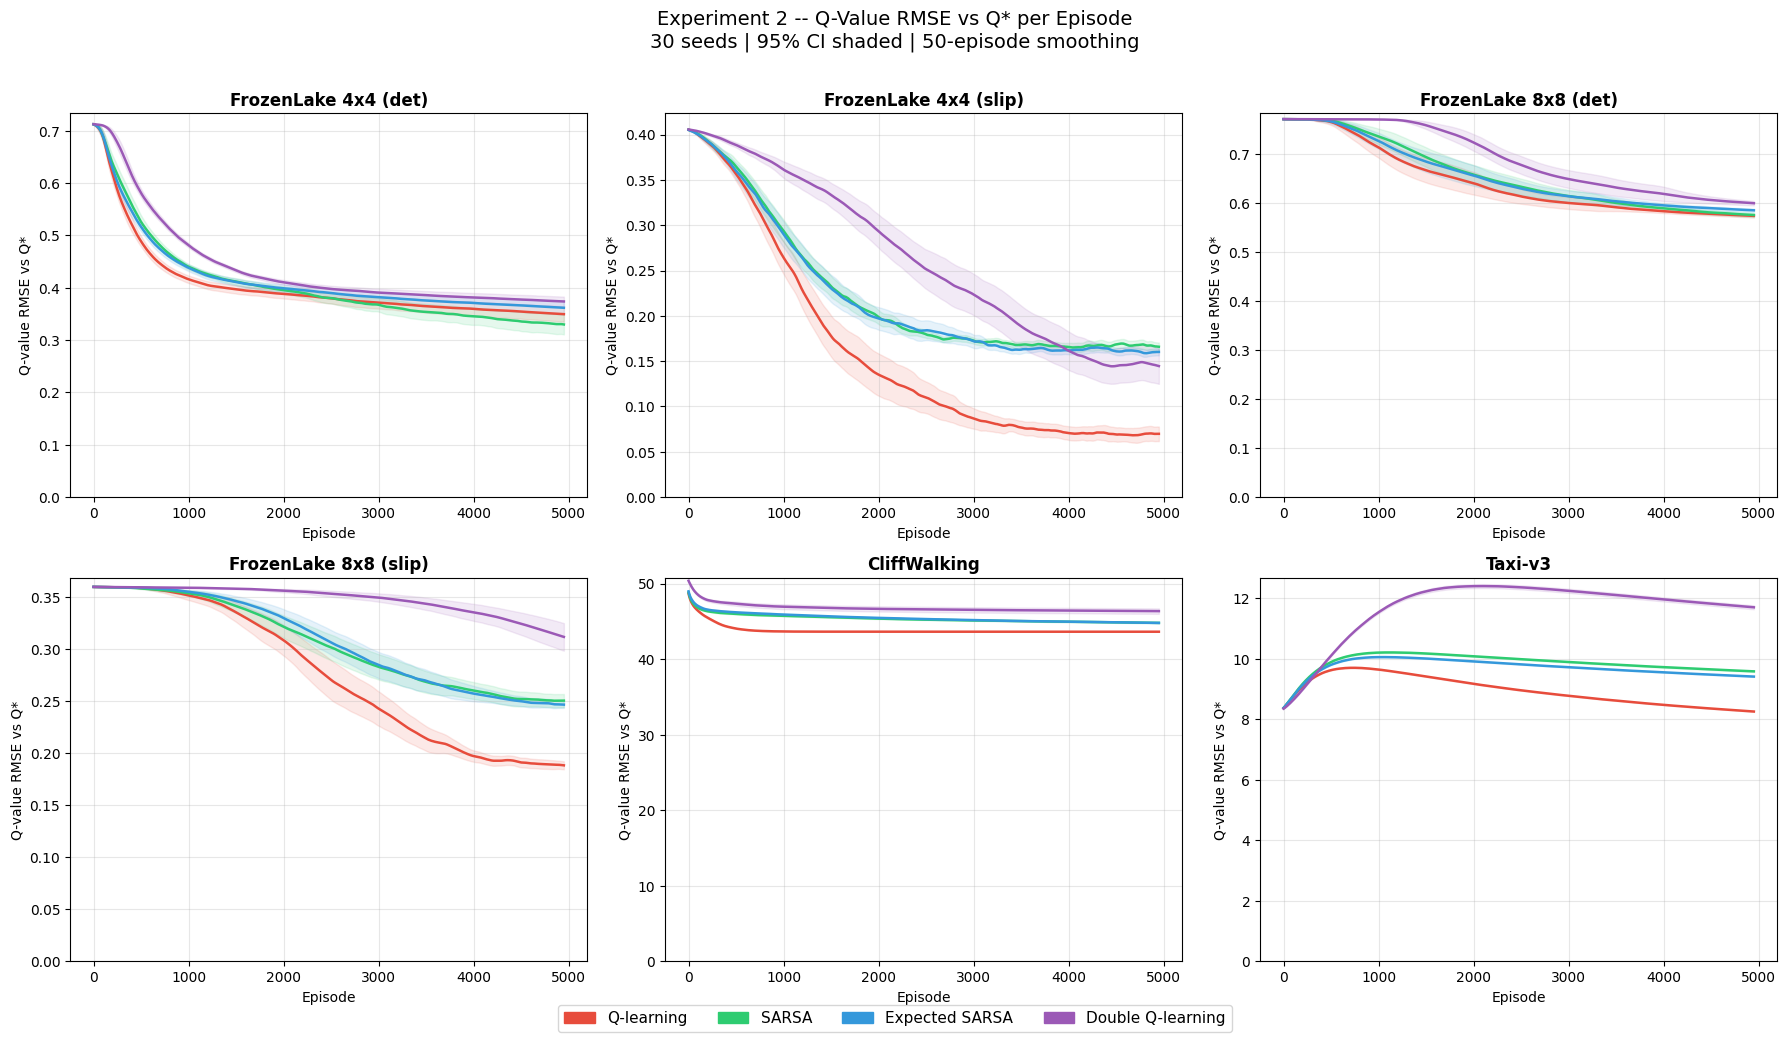

Saved: exp2_rmse_curves.png


In [ ]:
# Plot -- Q-Value RMSE vs Q*

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes      = axes.flatten()

for idx, env_key in enumerate(EXP2_ENVS):
    ax       = axes[idx]
    env_name = GymnasiumEnv._REGISTRY[env_key][4]

    for algo_name in ALGOS:
        data         = results[(env_key, algo_name)]['rmse']   # (30, 5000)
        mean, lo, hi = mean_ci(data, axis=0)

        m_s  = smooth(mean)
        lo_s = smooth(lo)
        hi_s = smooth(hi)
        ep_s = episodes[:len(m_s)]

        color = ALGO_COLORS[algo_name]
        ax.plot(ep_s, m_s, color=color, linewidth=1.8, label=algo_name)
        ax.fill_between(ep_s, lo_s, hi_s, color=color, alpha=0.12)

    ax.set_title(env_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode', fontsize=10)
    ax.set_ylabel('Q-value RMSE vs Q*', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

legend_patches = [mpatches.Patch(color=ALGO_COLORS[a], label=a) for a in ALGOS]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f'Experiment 2 -- Q-Value RMSE vs Q* per Episode\n'
    f'{N_SEEDS} seeds | 95% CI shaded | {SMOOTH_W}-episode smoothing',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/exp2_rmse_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp2_rmse_curves.png')

## What This Plot Shows

Each subplot tracks each algorithm's Q-table compared to the mathematically
correct Q* (computed via Value Iteration) over 5000 training episodes. This measure is called
**Q-value RMSE (Root Mean Squared Error)**. Every curve is the mean across **30 independent seeds**,
with the shaded region showing the **95% confidence interval** which is a measure of how consistent
the result is across runs. A narrow band means the algorithm behaves reliably; a wide band
means the outcome varies depending on random chance.

---

## Environment-by-Environment Observations

**FrozenLake 4×4 Deterministic**
All four algorithms converge smoothly and end up close to each other by episode 5000, with
RMSE around 0.32–0.38. Q-learning (red) converges slightly fastest. This is expected as in a
fully deterministic environment there is no noise, so Q-learning's tendency to overestimate
(maximization bias) does not get triggered. All algorithms are on roughly equal footing here.

**FrozenLake 4×4 Stochastic (slippery)**
This is where the algorithms start to separate. Q-learning (red) clearly outperforms the other
three, reaching a final RMSE near 0.07 while SARSA, Expected SARSA, and Double Q-learning
plateau around 0.15–0.17. This result is surprising at the start because we expected Double Q-learning
to outperform Q-learning here since stochasticity is exactly where maximization bias should
hurt Q-learning most. One likely explanation is that on a small 16-state environment, the bias
effect is not large enough to outweigh Q-learning's faster off-policy updates. Double Q-learning's
two-table mechanism may have added a layer of conservatism that may slow convergence on small environments.

**FrozenLake 8×8 Deterministic**
The larger state space (64 states) slows all algorithms down noticeably  as none come close to
converging by episode 5000, all sitting above RMSE 0.55. Q-learning and SARSA are marginally
ahead of Expected SARSA and Double Q-learning, but the differences are small. This environment
primarily demonstrates the scaling cost of tabular methods, the more states there are
the more experience is needed to accurately estimate every Q-value.

**FrozenLake 8×8 Stochastic (slippery)**
Here the hypothesis from our project begins to hold. Q-learning (red) achieves the lowest RMSE
(~0.19) by episode 5000, but the gap between algorithms is more visible than in the deterministic
case. Importantly, Double Q-learning (purple) lags furthest behind here, which is counter-intuitive.
This suggests that on tabular environments of this size, Double Q-learning's bias correction
may come at the cost of slower learning, a tradeoff that would likely reverse at larger scale
or with function approximation.

**CliffWalking**
All four algorithms show very high RMSE (~43–46) that barely decreases over 5000 episodes. This
does not mean the algorithms are failing rather CliffWalking is a cost-based environment where
every step costs -1 and falling off the cliff costs -100. The absolute Q* values are large
negative numbers, so even a well-learned policy will show high absolute RMSE. The important
observation here is that all four algorithms behave almost identically, and the confidence
intervals are extremely tight, meaning results are highly consistent across seeds. The algorithms
are learning, but RMSE alone is not the right metric to judge them on this environment.
Cumulative reward per episode tells the more meaningful story for CliffWalking.

**Taxi-v3**
This is the most complex environment because of 500 states and 6 actions. The RMSE curves here move
upward initially before coming down, which is a known behaviour in tabular RL on large
state spaces. Early in training, the agent visits only a small fraction of the 3000 state-action
pairs, and its Q-values for unvisited states are at their initial value . As the agent
explores more, it updates more cells and the RMSE relative to Q* temporarily rises before
the values start converging. Q-learning (red) handles this best, stabilising at the lowest
RMSE (~8.3) by episode 5000. Double Q-learning (purple) struggles most on this environment,
reaching the highest RMSE ( approx. 11.7), suggesting its conservative two-table update mechanism is
less sample-efficient at large scale under 5000 episodes.

---

## Overall Observation

1. A lower RMSE means the algorithm's learned Q-values are closer to the true optimal values.

2. Across all six environments, Q-learning consistently achieves the lowest or joint-lowest
RMSE, which aligns with its theoretical property of directly optimising toward Q* via the
off-policy Bellman update (Watkins & Dayan, 1992).

3. Double Q-learning which was designed to fix
Q-learning's maximization bias (Van Hasselt, 2010) shows slower convergence in most tabular
settings here, suggesting its advantage becomes more prominent in environments with stronger
stochastic noise or at larger scale than tested here.

4. SARSA and Expected SARSA perform
similarly to each other, generally sitting between Q-learning and Double Q-learning, consistent
with their on-policy nature which trades off some convergence speed for policy safety
(Rummery & Niranjan, 1994; Van Seijen et al., 2009).

# 10. Summary Table (All Metrics × All Environments)

In [ ]:
# Summary Table -- All Metrics x All Environments

import pandas as pd

summary_rows = []

for env_key in EXP2_ENVS:
    env_name = GymnasiumEnv._REGISTRY[env_key][4]
    Q_star   = q_stars[env_key]

    for algo_name, algo_fn in ALGOS.items():
        data    = results[(env_key, algo_name)]
        rewards = data['rewards']
        rmse    = data['rmse']

        final_r  = rewards[:, -100:].mean(axis=1)
        r_mu     = final_r.mean()
        r_ci     = 1.96 * stats.sem(final_r)


        final_rmse = rmse[:, -100:].mean(axis=1)
        rmse_mu  = final_rmse.mean()
        rmse_ci  = 1.96 * stats.sem(final_rmse)


        conv_speeds = [compute_convergence_speed(rewards[i]) for i in range(N_SEEDS)]
        conv_ep     = int(np.median(conv_speeds))


        env_tmp         = GymnasiumEnv.make(env_key)
        Q_final, _, _   = algo_fn(env_tmp, Q_star, seed=0)
        pol_opt         = compute_policy_optimality(Q_final, Q_star) * 100

        summary_rows.append({
            'Environment'      : env_name,
            'Algorithm'        : algo_name,
            'Final Reward mu'  : f'{r_mu:+.2f}',
            '+/- 95% CI'       : f'+-{r_ci:.2f}',
            'Final RMSE mu'    : f'{rmse_mu:.4f}',
            'RMSE 95% CI'      : f'+-{rmse_ci:.4f}',
            'Conv. Speed (ep)' : conv_ep,
            'Policy Opt. %'    : f'{pol_opt:.1f}%',
        })

df = pd.DataFrame(summary_rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.max_rows', 200)
print(df.to_string(index=False))

df.to_csv(f'{SAVE_DIR}/exp2_summary.csv', index=False)
print(f'\nSaved: exp2_summary.csv')

          Environment         Algorithm Final Reward mu +/- 95% CI Final RMSE mu RMSE 95% CI  Conv. Speed (ep) Policy Opt. %
 FrozenLake 4x4 (det)        Q-learning           +0.89     +-0.01        0.3499    +-0.0144              4834         81.2%
 FrozenLake 4x4 (det)             SARSA           +0.88     +-0.01        0.3303    +-0.0189              4879         93.8%
 FrozenLake 4x4 (det)    Expected SARSA           +0.89     +-0.01        0.3621    +-0.0125              4834         81.2%
 FrozenLake 4x4 (det) Double Q-learning           +0.89     +-0.01        0.3741    +-0.0092              4851         87.5%
FrozenLake 4x4 (slip)        Q-learning           +0.38     +-0.02        0.0698    +-0.0080              5000         93.8%
FrozenLake 4x4 (slip)             SARSA           +0.38     +-0.02        0.1661    +-0.0046              5000         87.5%
FrozenLake 4x4 (slip)    Expected SARSA           +0.37     +-0.02        0.1601    +-0.0037              5000         87.5%
